# Lựa chọn đặc trưng (Feature Selection) cho bài toán dự đoán giá nhà

**Bộ dữ liệu:** `Data/House Price Prediction Dataset.csv` (2000 mẫu, biến mục tiêu `Price`)  
**Mô hình so sánh:** SVR, XGBoost, RandomForest  
**Phương pháp chọn đặc trưng:** Filter (Pearson, Mutual Information, f_regression) · Wrapper (RFE, Sequential Feature Selection) · Embedded (Lasso, feature importance của RandomForest / XGBoost) · Baseline (không chọn đặc trưng)  
**Thước đo:** R², RMSE, MAE, thời gian huấn luyện + dự đoán

**Cấu trúc notebook**

1. Tiền xử lý và hàm dùng chung
2. Filter methods
3. Wrapper và Embedded methods
4. Baseline và tổng hợp kết quả



In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
DATA_PATH = os.path.join("Data", "House Price Prediction Dataset.csv")
TOP_K = 6          # số đặc trưng giữ lại cho mọi phương pháp chọn đặc trưng
MODEL_ORDER = ["SVR", "XGBoost", "RandomForest"]

print("Thư mục làm việc :", os.getcwd())
print("File dữ liệu tồn tại:", os.path.exists(DATA_PATH))

Thư mục làm việc : d:\mayhoc\Machine-learning\Tuan05\New folder
File dữ liệu tồn tại: True


---
# PHẦN 1: Tiền xử lý và hàm dùng chung

Nội dung: bỏ `Id`, kiểm tra trùng lặp / outlier, one-hot encoding, chuẩn hóa (cần cho SVM), chia train/test 80/20, viết `preprocess.py` và hàm `evaluate(model, features)` trả về R², RMSE, MAE và thời gian.

## 1.1. File `preprocess.py`

Cell dưới đây ghi ra file `preprocess.py` (cùng thư mục với notebook). Các phần sau import trực tiếp từ file này nên bộ dữ liệu chia train/test và hàm `evaluate` được dùng chung cho cả nhóm.

In [2]:
%%writefile preprocess.py
"""
preprocess.py - Tiền xử lý dữ liệu và các hàm dùng chung
Bộ dữ liệu: House Price Prediction Dataset (biến mục tiêu: Price)
"""
import time

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

DATA_PATH = "Data/House Price Prediction Dataset.csv"
TARGET = "Price"
RANDOM_STATE = 42
TEST_SIZE = 0.2


# ----------------------------------------------------------------------------
# 1. Đọc dữ liệu và làm sạch
# ----------------------------------------------------------------------------
def load_data(path=DATA_PATH):
    """Đọc file CSV."""
    return pd.read_csv(path)


def drop_id(df):
    """Bỏ cột Id (chỉ là số thứ tự, không mang thông tin dự đoán)."""
    return df.drop(columns=["Id"], errors="ignore")


def check_duplicates(df, remove=True):
    """Đếm dòng trùng lặp; mặc định loại bỏ."""
    n_dup = int(df.duplicated().sum())
    if remove and n_dup > 0:
        df = df.drop_duplicates().reset_index(drop=True)
    return df, n_dup


def detect_outliers_iqr(df, columns=None, factor=1.5):
    """Thống kê outlier theo quy tắc IQR cho từng cột số."""
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns
    rows = []
    for col in columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - factor * iqr, q3 + factor * iqr
        n_out = int(((df[col] < low) | (df[col] > high)).sum())
        rows.append({"Cột": col, "Q1": q1, "Q3": q3, "Cận dưới": low,
                     "Cận trên": high, "Số outlier": n_out,
                     "Tỉ lệ (%)": 100 * n_out / len(df)})
    return pd.DataFrame(rows)


def remove_outliers_iqr(df, columns, factor=1.5):
    """Loại các dòng có outlier (không dùng mặc định, chỉ để tham khảo)."""
    mask = pd.Series(True, index=df.index)
    for col in columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        mask &= df[col].between(q1 - factor * iqr, q3 + factor * iqr)
    return df[mask].reset_index(drop=True)


# ----------------------------------------------------------------------------
# 2. One-hot encoding, chia train/test, chuẩn hóa
# ----------------------------------------------------------------------------
def encode_onehot(df):
    """One-hot encoding cho các cột phân loại (drop_first tránh đa cộng tuyến)."""
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    return pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)


def preprocess(path=DATA_PATH, test_size=TEST_SIZE, random_state=RANDOM_STATE,
               remove_outliers=False):
    """
    Quy trình đầy đủ: đọc -> bỏ Id -> bỏ trùng lặp -> (tuỳ chọn) bỏ outlier
    -> one-hot -> chia train/test 80/20 -> chuẩn hóa (fit trên train).
    Trả về: X_train, X_test, y_train, y_test, scaler
    """
    df = drop_id(load_data(path))
    df, _ = check_duplicates(df, remove=True)
    if remove_outliers:
        df = remove_outliers_iqr(df, df.select_dtypes(include=np.number).columns)
    df = encode_onehot(df)

    X = df.drop(columns=[TARGET])
    y = df[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train),
                           columns=X.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test),
                          columns=X.columns, index=X_test.index)
    return X_train, X_test, y_train, y_test, scaler


# Dữ liệu dùng chung: nạp một lần khi import file này
X_train, X_test, y_train, y_test, scaler = preprocess()
FEATURES = X_train.columns.tolist()


# ----------------------------------------------------------------------------
# 3. Mô hình và hàm đánh giá dùng chung
# ----------------------------------------------------------------------------
def get_models():
    """Ba mô hình dùng chung cho toàn nhóm. SVR được chuẩn hóa thêm biến mục tiêu
    vì Price có đơn vị lớn (cỡ 10^5 - 10^6)."""
    return {
        "SVR": TransformedTargetRegressor(
            regressor=SVR(kernel="rbf", C=1.0, epsilon=0.1),
            transformer=StandardScaler()),
        "XGBoost": XGBRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=4,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        "RandomForest": RandomForestRegressor(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    }


def evaluate(model, features):
    """
    Huấn luyện `model` trên tập train với danh sách `features`, dự đoán trên test.
    Trả về dict: R2, RMSE, MAE, Time (giây; gồm huấn luyện + dự đoán).
    """
    features = list(features)
    est = clone(model)
    start = time.perf_counter()
    est.fit(X_train[features], y_train)
    y_pred = est.predict(X_test[features])
    elapsed = time.perf_counter() - start
    return {
        "R2": r2_score(y_test, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAE": mean_absolute_error(y_test, y_pred),
        "Time": elapsed,
    }


def run_experiment(method, features):
    """Chạy cả 3 mô hình với một tập đặc trưng, trả về DataFrame kết quả."""
    features = list(features)
    rows = []
    for name, model in get_models().items():
        res = evaluate(model, features)
        rows.append({"Method": method, "Model": name,
                     "n_features": len(features),
                     "Features": ", ".join(features), **res})
    return pd.DataFrame(rows)

Writing preprocess.py


## 1.2. Đọc dữ liệu và bỏ cột `Id`

In [3]:
import importlib
import preprocess as pp
importlib.reload(pp)

df_raw = pp.load_data(DATA_PATH)
print("Kích thước dữ liệu gốc:", df_raw.shape)
display(df_raw.head())
print()
df_raw.info()

Kích thước dữ liệu gốc: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [4]:
df = pp.drop_id(df_raw)
print("Sau khi bỏ Id:", df.shape)
print("Giá trị thiếu mỗi cột:")
print(df.isna().sum().to_string())
display(df.describe().T)

Sau khi bỏ Id: (2000, 9)
Giá trị thiếu mỗi cột:
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0


,count,mean,std,min,25%,50%,75%,max
Area,"2,000.0000","2,786.2095","1,295.1468",501.0000,"1,653.0000","2,833.0000","3,887.5000","4,999.0000"
Bedrooms,"2,000.0000",3.0035,1.4246,1.0000,2.0000,3.0000,4.0000,5.0000
Bathrooms,"2,000.0000",2.5525,1.1090,1.0000,2.0000,3.0000,4.0000,4.0000
Floors,"2,000.0000",1.9935,0.8092,1.0000,1.0000,2.0000,3.0000,3.0000
YearBuilt,"2,000.0000","1,961.4460",35.9267,"1,900.0000","1,930.0000","1,961.0000","1,993.0000","2,023.0000"
Price,"2,000.0000","537,676.8550","276,428.8457","50,005.0000","300,098.0000","539,254.0000","780,086.0000","999,656.0000"


## 1.3. Kiểm tra trùng lặp và outlier

Số dòng trùng lặp: 0 (đã loại bỏ nếu có) -> còn 2000 dòng


,Cột,Q1,Q3,Cận dưới,Cận trên,Số outlier,Tỉ lệ (%)
0,Area,"1,653.0000","3,887.5000","-1,698.7500","7,239.2500",0,0.0000
1,Bedrooms,2.0000,4.0000,-1.0000,7.0000,0,0.0000
2,Bathrooms,2.0000,4.0000,-1.0000,7.0000,0,0.0000
3,Floors,1.0000,3.0000,-2.0000,6.0000,0,0.0000
4,YearBuilt,"1,930.0000","1,993.0000","1,835.5000","2,087.5000",0,0.0000
5,Price,"300,098.0000","780,086.0000","-419,884.0000","1,500,068.0000",0,0.0000


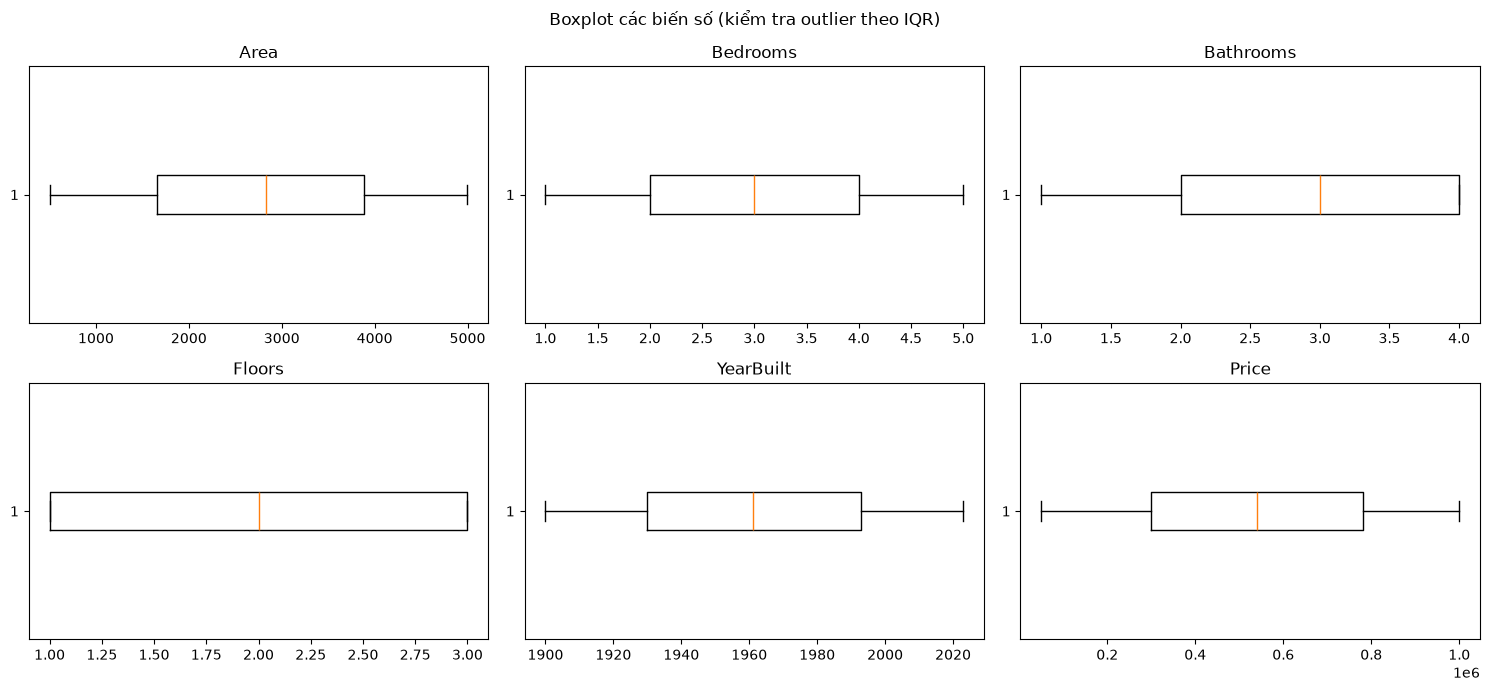

In [5]:
df, n_dup = pp.check_duplicates(df, remove=True)
print(f"Số dòng trùng lặp: {n_dup} (đã loại bỏ nếu có) -> còn {len(df)} dòng")

outlier_report = pp.detect_outliers_iqr(df)
display(outlier_report)

num_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), num_cols):
    ax.boxplot(df[col], vert=False)
    ax.set_title(col)
plt.suptitle("Boxplot các biến số (kiểm tra outlier theo IQR)")
plt.tight_layout()
plt.show()

In [6]:
total_outliers = int(outlier_report["Số outlier"].sum())
if total_outliers == 0:
    print("Không phát hiện outlier theo quy tắc IQR -> giữ nguyên toàn bộ dữ liệu.")
else:
    print(f"Phát hiện {total_outliers} giá trị outlier theo IQR. "
          "Các giá trị này nằm trong khoảng hợp lệ của dữ liệu nên được giữ lại (remove_outliers=False).")

Không phát hiện outlier theo quy tắc IQR -> giữ nguyên toàn bộ dữ liệu.


## 1.4. One-hot encoding

In [7]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print("Các cột phân loại:", cat_cols)
for c in cat_cols:
    print(f"  {c}: {df[c].unique().tolist()}")

df_encoded = pp.encode_onehot(df)
print("\nKích thước sau one-hot:", df_encoded.shape)
display(df_encoded.head())

Các cột phân loại: ['Location', 'Condition', 'Garage']
  Location: ['Downtown', 'Suburban', 'Urban', 'Rural']
  Condition: ['Excellent', 'Good', 'Fair', 'Poor']
  Garage: ['No', 'Yes']

Kích thước sau one-hot: (2000, 13)


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,4272,5,4,3,1958,424998,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,3592,2,2,3,1938,266746,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
3,966,4,2,2,1902,244020,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000
4,4926,1,4,2,1975,636056,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000


## 1.5. Chia train/test 80/20 và chuẩn hóa

In [8]:
X_train, X_test, y_train, y_test, scaler = pp.preprocess(DATA_PATH)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print(f"Tỉ lệ train/test: {len(X_train)/(len(X_train)+len(X_test)):.0%} / {len(X_test)/(len(X_train)+len(X_test)):.0%}")
print("\nDanh sách đặc trưng:", X_train.columns.tolist())

check = pd.DataFrame({"mean (train)": X_train.mean(), "std (train)": X_train.std()})
display(check)

X_train: (1600, 12) | X_test: (400, 12)
y_train: (1600,) | y_test: (400,)
Tỉ lệ train/test: 80% / 20%

Danh sách đặc trưng: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


,mean (train),std (train)
Area,-0.0000,1.0003
Bedrooms,-0.0000,1.0003
Bathrooms,0.0000,1.0003
Floors,-0.0000,1.0003
YearBuilt,-0.0000,1.0003
Location_Rural,0.0000,1.0003
Location_Suburban,-0.0000,1.0003
Location_Urban,-0.0000,1.0003
Condition_Fair,-0.0000,1.0003
Condition_Good,0.0000,1.0003


## 1.6. Kiểm tra hàm `evaluate(model, features)`

In [9]:
FEATURES = pp.FEATURES
models = pp.get_models()

demo = pp.evaluate(models["RandomForest"], FEATURES)
print("Ví dụ evaluate(RandomForest, tất cả đặc trưng):")
for k, v in demo.items():
    print(f"  {k:5s}: {v:,.4f}")

Ví dụ evaluate(RandomForest, tất cả đặc trưng):
  R2   : -0.0913
  RMSE : 291,380.5184
  MAE  : 251,003.0876
  Time : 0.8501


---
# PHẦN 2: Filter methods

Nội dung: Pearson correlation, Mutual Information, f_regression (ANOVA); chọn top K đặc trưng, chạy SVR, XGBoost, RandomForest và ghi kết quả.

In [10]:
from sklearn.feature_selection import f_regression, mutual_info_regression

train_df = X_train.copy()
train_df["Price"] = y_train

# --- Pearson: |hệ số tương quan| giữa từng đặc trưng và Price
pearson_signed = train_df.corr()["Price"].drop("Price")
pearson_score = pearson_signed.abs()

# --- Mutual Information
mi_score = pd.Series(
    mutual_info_regression(X_train, y_train, random_state=RANDOM_STATE),
    index=X_train.columns)

# --- f_regression (ANOVA F-test)
f_stat, f_pval = f_regression(X_train, y_train)
f_score = pd.Series(f_stat, index=X_train.columns)

filter_scores = pd.DataFrame({
    "Pearson (|r|)": pearson_score,
    "Pearson (r)": pearson_signed,
    "Mutual Info": mi_score,
    "F-statistic": f_score,
    "F p-value": pd.Series(f_pval, index=X_train.columns),
}).sort_values("Pearson (|r|)", ascending=False)
display(filter_scores)

,Pearson (|r|),Pearson (r),Mutual Info,F-statistic,F p-value
Floors,0.0681,0.0681,0.0000,7.4411,0.0064
Condition_Fair,0.0452,0.0452,0.0088,3.2727,0.0706
Bathrooms,0.0393,-0.0393,0.0000,2.4667,0.1165
Condition_Good,0.0357,-0.0357,0.0049,2.0449,0.1529
Location_Urban,0.0256,-0.0256,0.0000,1.0480,0.3061
Location_Suburban,0.0228,0.0228,0.0000,0.8277,0.3631
YearBuilt,0.0144,0.0144,0.0000,0.3331,0.5639
Location_Rural,0.0049,0.0049,0.0139,0.0378,0.8460
Garage_Yes,0.0038,0.0038,0.0036,0.0234,0.8785
Area,0.0009,-0.0009,0.0000,0.0012,0.9723


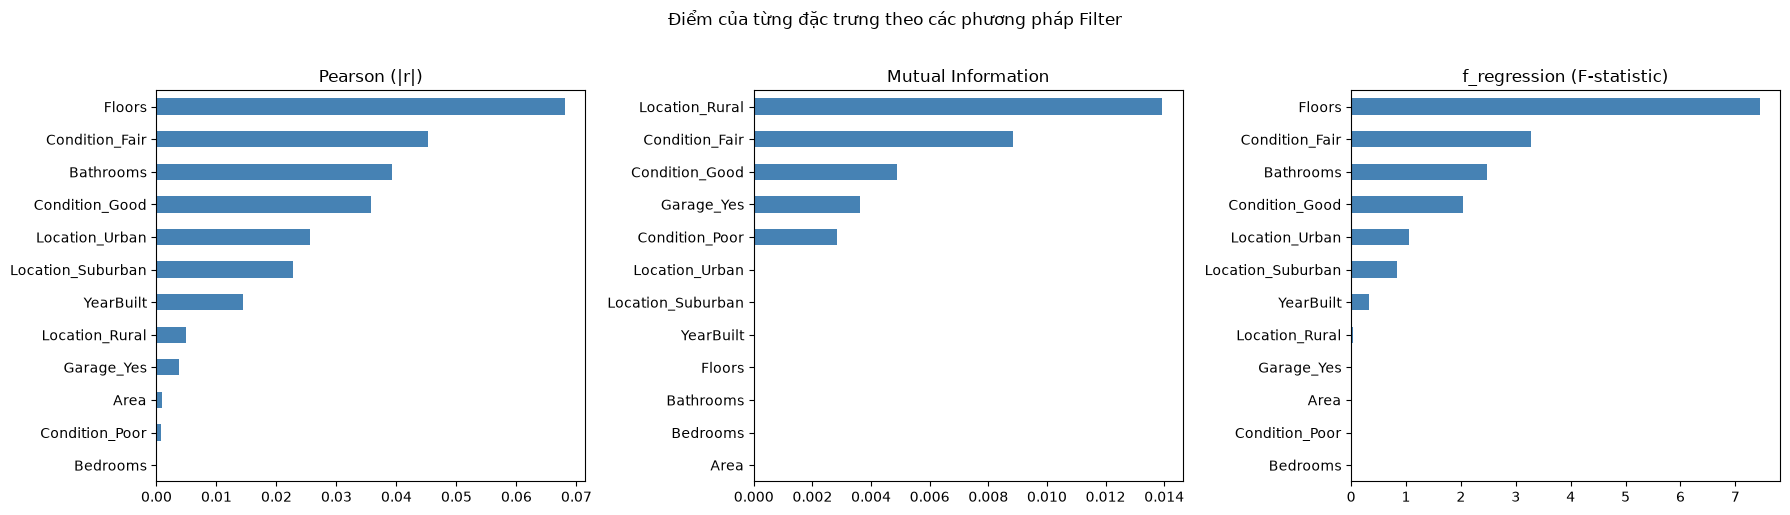

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, s) in zip(axes, [("Pearson (|r|)", pearson_score),
                                 ("Mutual Information", mi_score),
                                 ("f_regression (F-statistic)", f_score)]):
    s.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(title)
plt.suptitle("Điểm của từng đặc trưng theo các phương pháp Filter", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
def top_k_features(score, k=TOP_K):
    return score.sort_values(ascending=False).head(k).index.tolist()

filter_sets = {
    "Filter - Pearson": top_k_features(pearson_score),
    "Filter - Mutual Info": top_k_features(mi_score),
    "Filter - f_regression": top_k_features(f_score),
}

print(f"Top {TOP_K} đặc trưng của từng phương pháp Filter:")
for name, feats in filter_sets.items():
    print(f"\n{name}:\n   {feats}")

Top 6 đặc trưng của từng phương pháp Filter:

Filter - Pearson:
   ['Floors', 'Condition_Fair', 'Bathrooms', 'Condition_Good', 'Location_Urban', 'Location_Suburban']

Filter - Mutual Info:
   ['Location_Rural', 'Condition_Fair', 'Condition_Good', 'Garage_Yes', 'Condition_Poor', 'Bathrooms']

Filter - f_regression:
   ['Floors', 'Condition_Fair', 'Bathrooms', 'Condition_Good', 'Location_Urban', 'Location_Suburban']


In [13]:
results_filter = pd.concat(
    [pp.run_experiment(name, feats) for name, feats in filter_sets.items()],
    ignore_index=True)

display(results_filter.drop(columns="Features"))

,Method,Model,n_features,R2,RMSE,MAE,Time
0,Filter - Pearson,SVR,6,-0.0610,"287,311.6969","247,330.5200",0.1829
1,Filter - Pearson,XGBoost,6,-0.0351,"283,771.4244","245,527.5000",0.4976
2,Filter - Pearson,RandomForest,6,-0.0755,"289,266.2228","247,879.7032",0.4577
3,Filter - Mutual Info,SVR,6,-0.0628,"287,543.6693","248,780.7242",0.1579
4,Filter - Mutual Info,XGBoost,6,-0.0474,"285,459.3428","247,531.6562",0.3374
5,Filter - Mutual Info,RandomForest,6,-0.0484,"285,590.7384","247,213.3190",0.4897
6,Filter - f_regression,SVR,6,-0.0610,"287,311.6969","247,330.5200",0.1551
7,Filter - f_regression,XGBoost,6,-0.0351,"283,771.4244","245,527.5000",0.4123
8,Filter - f_regression,RandomForest,6,-0.0755,"289,266.2228","247,879.7032",0.4581


---
# PHẦN 3: Wrapper và Embedded

Nội dung: RFE, Sequential Feature Selection (Wrapper); Lasso, feature importance của RandomForest / XGBoost (Embedded). Chạy 3 mô hình với từng tập đặc trưng.

## 3.1. Wrapper methods

In [14]:
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# --- RFE (loại dần đặc trưng kém quan trọng, ước lượng bằng RandomForest)
rfe = RFE(
    estimator=RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    n_features_to_select=TOP_K, step=1)
rfe.fit(X_train, y_train)
rfe_features = X_train.columns[rfe.support_].tolist()

rfe_ranking = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()
print("RFE - xếp hạng (1 = được giữ lại):")
display(rfe_ranking.to_frame("Ranking"))
print("RFE chọn:", rfe_features)

RFE - xếp hạng (1 = được giữ lại):


,Ranking
Area,1
Bedrooms,1
Bathrooms,1
Floors,1
YearBuilt,1
Location_Rural,1
Garage_Yes,2
Condition_Poor,3
Location_Urban,4
Condition_Fair,5


RFE chọn: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location_Rural']


In [15]:
# --- Sequential Feature Selection (forward, đánh giá bằng cross-validation 5-fold trên train)
sfs = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=TOP_K,
    direction="forward", scoring="r2", cv=5, n_jobs=-1)
sfs.fit(X_train, y_train)
sfs_features = X_train.columns[sfs.get_support()].tolist()
print("Sequential Feature Selection (forward) chọn:", sfs_features)

Sequential Feature Selection (forward) chọn: ['Bathrooms', 'Floors', 'Location_Suburban', 'Location_Urban', 'Condition_Good', 'Condition_Poor']


## 3.2. Embedded methods

In [16]:
# --- Lasso (LassoCV tự chọn alpha bằng cross-validation)
from sklearn.linear_model import lasso_path

lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000)
lasso.fit(X_train, y_train)
lasso_coef = pd.Series(lasso.coef_, index=X_train.columns)
n_nonzero = int((lasso_coef != 0).sum())

print(f"alpha tối ưu của Lasso (CV): {lasso.alpha_:,.4f}")
print(f"Số hệ số khác 0: {n_nonzero} / {len(lasso_coef)}")

if n_nonzero >= TOP_K:
    # Đủ hệ số khác 0 -> chọn top K theo |hệ số|
    lasso_score = lasso_coef.abs()
    lasso_features = lasso_score.sort_values(ascending=False).head(TOP_K).index.tolist()
else:
    # Alpha tối ưu phạt quá mạnh (gần như mọi hệ số về 0) -> dùng đường đi regularization:
    # đặc trưng nào có hệ số khác 0 ở alpha lớn hơn (vào mô hình sớm hơn) được xếp quan trọng hơn.
    alphas, coefs, _ = lasso_path(X_train.values, y_train.values, n_alphas=200)
    entry_alpha = pd.Series(
        [alphas[np.nonzero(coefs[i])[0][0]] if np.any(coefs[i] != 0) else 0.0
         for i in range(coefs.shape[0])],
        index=X_train.columns)
    lasso_score = entry_alpha / entry_alpha.max()
    lasso_features = lasso_score.sort_values(ascending=False).head(TOP_K).index.tolist()
    print("-> Hệ số ở alpha tối ưu quá ít/toàn bằng 0, chọn theo thứ tự đặc trưng xuất hiện trên đường đi Lasso.")

display(lasso_score.sort_values(ascending=False).to_frame("Điểm Lasso"))
print("Lasso chọn:", lasso_features)

alpha tối ưu của Lasso (CV): 18,769.3405
Số hệ số khác 0: 0 / 12
-> Hệ số ở alpha tối ưu quá ít/toàn bằng 0, chọn theo thứ tự đặc trưng xuất hiện trên đường đi Lasso.


,Điểm Lasso
Floors,1.0000
Condition_Fair,0.6826
Bathrooms,0.5941
Condition_Good,0.4660
Location_Urban,0.3917
Location_Suburban,0.3293
YearBuilt,0.2248
Garage_Yes,0.0691
Condition_Poor,0.0644
Area,0.0410


Lasso chọn: ['Floors', 'Condition_Fair', 'Bathrooms', 'Condition_Good', 'Location_Urban', 'Location_Suburban']


In [17]:
# --- Feature importance của RandomForest
rf_sel = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train, y_train)
rf_importance = pd.Series(rf_sel.feature_importances_, index=X_train.columns)
rf_features = rf_importance.sort_values(ascending=False).head(TOP_K).index.tolist()

# --- Feature importance của XGBoost
xgb_sel = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                       random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_sel.fit(X_train, y_train)
xgb_importance = pd.Series(xgb_sel.feature_importances_, index=X_train.columns)
xgb_features = xgb_importance.sort_values(ascending=False).head(TOP_K).index.tolist()

print("RandomForest importance chọn:", rf_features)
print("XGBoost importance chọn     :", xgb_features)

RandomForest importance chọn: ['Area', 'YearBuilt', 'Bedrooms', 'Bathrooms', 'Floors', 'Garage_Yes']
XGBoost importance chọn     : ['Location_Urban', 'Location_Suburban', 'Location_Rural', 'Bathrooms', 'Garage_Yes', 'Area']


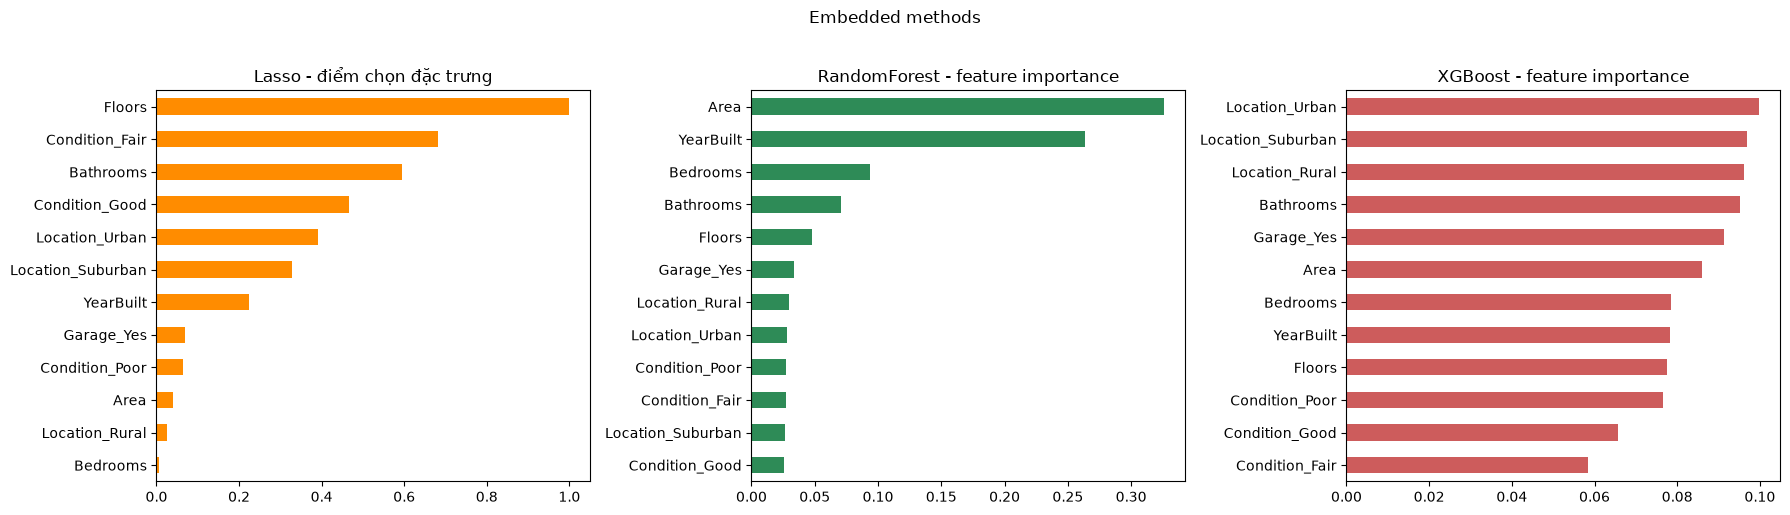

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lasso_score.sort_values().plot.barh(ax=axes[0], color="darkorange")
axes[0].set_title("Lasso - điểm chọn đặc trưng")
rf_importance.sort_values().plot.barh(ax=axes[1], color="seagreen")
axes[1].set_title("RandomForest - feature importance")
xgb_importance.sort_values().plot.barh(ax=axes[2], color="indianred")
axes[2].set_title("XGBoost - feature importance")
plt.suptitle("Embedded methods", y=1.02)
plt.tight_layout()
plt.show()

## 3.3. Chạy 3 mô hình với từng tập đặc trưng

In [19]:
wrapper_embedded_sets = {
    "Wrapper - RFE": rfe_features,
    "Wrapper - SFS": sfs_features,
    "Embedded - Lasso": lasso_features,
    "Embedded - RF importance": rf_features,
    "Embedded - XGB importance": xgb_features,
}

results_wrapper_embedded = pd.concat(
    [pp.run_experiment(name, feats) for name, feats in wrapper_embedded_sets.items()],
    ignore_index=True)

display(results_wrapper_embedded.drop(columns="Features"))

,Method,Model,n_features,R2,RMSE,MAE,Time
0,Wrapper - RFE,SVR,6,-0.0978,"292,250.9198","251,700.9387",0.1662
1,Wrapper - RFE,XGBoost,6,-0.0585,"286,965.5520","249,324.2188",0.5644
2,Wrapper - RFE,RandomForest,6,-0.1301,"296,513.7833","258,229.4297",0.6568
3,Wrapper - SFS,SVR,6,-0.0772,"289,494.5228","249,021.8288",0.1702
4,Wrapper - SFS,XGBoost,6,-0.0526,"286,171.1318","247,322.3594",0.4045
5,Wrapper - SFS,RandomForest,6,-0.0898,"291,172.2636","250,208.7932",0.5767
6,Embedded - Lasso,SVR,6,-0.0610,"287,311.6969","247,330.5200",0.1499
7,Embedded - Lasso,XGBoost,6,-0.0351,"283,771.4244","245,527.5000",0.6755
8,Embedded - Lasso,RandomForest,6,-0.0755,"289,266.2228","247,879.7032",0.5590
9,Embedded - RF importance,SVR,6,-0.0842,"290,436.3073","249,810.8855",0.1562


---
# PHẦN 4: Baseline và tổng hợp kết quả

Nội dung: chạy baseline (không chọn đặc trưng) để so sánh; tổng hợp kết quả cả nhóm thành bảng và biểu đồ (R², RMSE, thời gian).

## 4.1. Baseline (không chọn đặc trưng)

In [20]:
results_baseline = pp.run_experiment("Baseline (tất cả đặc trưng)", FEATURES)
display(results_baseline.drop(columns="Features"))

,Method,Model,n_features,R2,RMSE,MAE,Time
0,Baseline (tất cả đặc trưng),SVR,12,-0.1780,"302,735.3308","259,288.4611",0.2427
1,Baseline (tất cả đặc trưng),XGBoost,12,-0.0719,"288,778.7516","249,126.9219",0.4341
2,Baseline (tất cả đặc trưng),RandomForest,12,-0.0913,"291,380.5184","251,003.0876",0.7156


## 4.2. Tổng hợp kết quả của cả nhóm

In [21]:
all_results = pd.concat(
    [results_baseline, results_filter, results_wrapper_embedded],
    ignore_index=True)

method_order = all_results["Method"].unique().tolist()
all_results["Method"] = pd.Categorical(all_results["Method"], categories=method_order, ordered=True)
all_results["Model"] = pd.Categorical(all_results["Model"], categories=MODEL_ORDER, ordered=True)
all_results = all_results.sort_values(["Method", "Model"]).reset_index(drop=True)

summary = all_results[["Method", "Model", "n_features", "R2", "RMSE", "MAE", "Time"]].rename(
    columns={"n_features": "Số đặc trưng", "Time": "Thời gian (s)"})
display(summary)

summary.to_csv("ket_qua_tong_hop.csv", index=False, encoding="utf-8-sig")
print("Đã lưu bảng tổng hợp: ket_qua_tong_hop.csv")

,Method,Model,Số đặc trưng,R2,RMSE,MAE,Thời gian (s)
0,Baseline (tất cả đặc trưng),SVR,12,-0.1780,"302,735.3308","259,288.4611",0.2427
1,Baseline (tất cả đặc trưng),XGBoost,12,-0.0719,"288,778.7516","249,126.9219",0.4341
2,Baseline (tất cả đặc trưng),RandomForest,12,-0.0913,"291,380.5184","251,003.0876",0.7156
3,Filter - Pearson,SVR,6,-0.0610,"287,311.6969","247,330.5200",0.1829
4,Filter - Pearson,XGBoost,6,-0.0351,"283,771.4244","245,527.5000",0.4976
5,Filter - Pearson,RandomForest,6,-0.0755,"289,266.2228","247,879.7032",0.4577
6,Filter - Mutual Info,SVR,6,-0.0628,"287,543.6693","248,780.7242",0.1579
7,Filter - Mutual Info,XGBoost,6,-0.0474,"285,459.3428","247,531.6562",0.3374
8,Filter - Mutual Info,RandomForest,6,-0.0484,"285,590.7384","247,213.3190",0.4897
9,Filter - f_regression,SVR,6,-0.0610,"287,311.6969","247,330.5200",0.1551


Đã lưu bảng tổng hợp: ket_qua_tong_hop.csv


In [22]:
for metric, label in [("R2", "R²"), ("RMSE", "RMSE"), ("MAE", "MAE"), ("Time", "Thời gian (s)")]:
    pv = all_results.pivot(index="Method", columns="Model", values=metric)[MODEL_ORDER]
    print(f"\n=== {label} ===")
    display(pv)


=== R² ===


Model,SVR,XGBoost,RandomForest
Method,,,
Baseline (tất cả đặc trưng),-0.1780,-0.0719,-0.0913
Filter - Pearson,-0.0610,-0.0351,-0.0755
Filter - Mutual Info,-0.0628,-0.0474,-0.0484
Filter - f_regression,-0.0610,-0.0351,-0.0755
Wrapper - RFE,-0.0978,-0.0585,-0.1301
Wrapper - SFS,-0.0772,-0.0526,-0.0898
Embedded - Lasso,-0.0610,-0.0351,-0.0755
Embedded - RF importance,-0.0842,-0.0594,-0.0980
Embedded - XGB importance,-0.1009,-0.0955,-0.2483



=== RMSE ===


Model,SVR,XGBoost,RandomForest
Method,,,
Baseline (tất cả đặc trưng),"302,735.3308","288,778.7516","291,380.5184"
Filter - Pearson,"287,311.6969","283,771.4244","289,266.2228"
Filter - Mutual Info,"287,543.6693","285,459.3428","285,590.7384"
Filter - f_regression,"287,311.6969","283,771.4244","289,266.2228"
Wrapper - RFE,"292,250.9198","286,965.5520","296,513.7833"
Wrapper - SFS,"289,494.5228","286,171.1318","291,172.2636"
Embedded - Lasso,"287,311.6969","283,771.4244","289,266.2228"
Embedded - RF importance,"290,436.3073","287,082.7990","292,273.2687"
Embedded - XGB importance,"292,653.8131","291,933.8095","311,640.0148"



=== MAE ===


Model,SVR,XGBoost,RandomForest
Method,,,
Baseline (tất cả đặc trưng),"259,288.4611","249,126.9219","251,003.0876"
Filter - Pearson,"247,330.5200","245,527.5000","247,879.7032"
Filter - Mutual Info,"248,780.7242","247,531.6562","247,213.3190"
Filter - f_regression,"247,330.5200","245,527.5000","247,879.7032"
Wrapper - RFE,"251,700.9387","249,324.2188","258,229.4297"
Wrapper - SFS,"249,021.8288","247,322.3594","250,208.7932"
Embedded - Lasso,"247,330.5200","245,527.5000","247,879.7032"
Embedded - RF importance,"249,810.8855","249,302.3594","252,859.8040"
Embedded - XGB importance,"252,470.7120","250,856.3438","260,930.1097"



=== Thời gian (s) ===


Model,SVR,XGBoost,RandomForest
Method,,,
Baseline (tất cả đặc trưng),0.2427,0.4341,0.7156
Filter - Pearson,0.1829,0.4976,0.4577
Filter - Mutual Info,0.1579,0.3374,0.4897
Filter - f_regression,0.1551,0.4123,0.4581
Wrapper - RFE,0.1662,0.5644,0.6568
Wrapper - SFS,0.1702,0.4045,0.5767
Embedded - Lasso,0.1499,0.6755,0.5590
Embedded - RF importance,0.1562,0.3774,0.6185
Embedded - XGB importance,0.1631,0.5343,0.6288


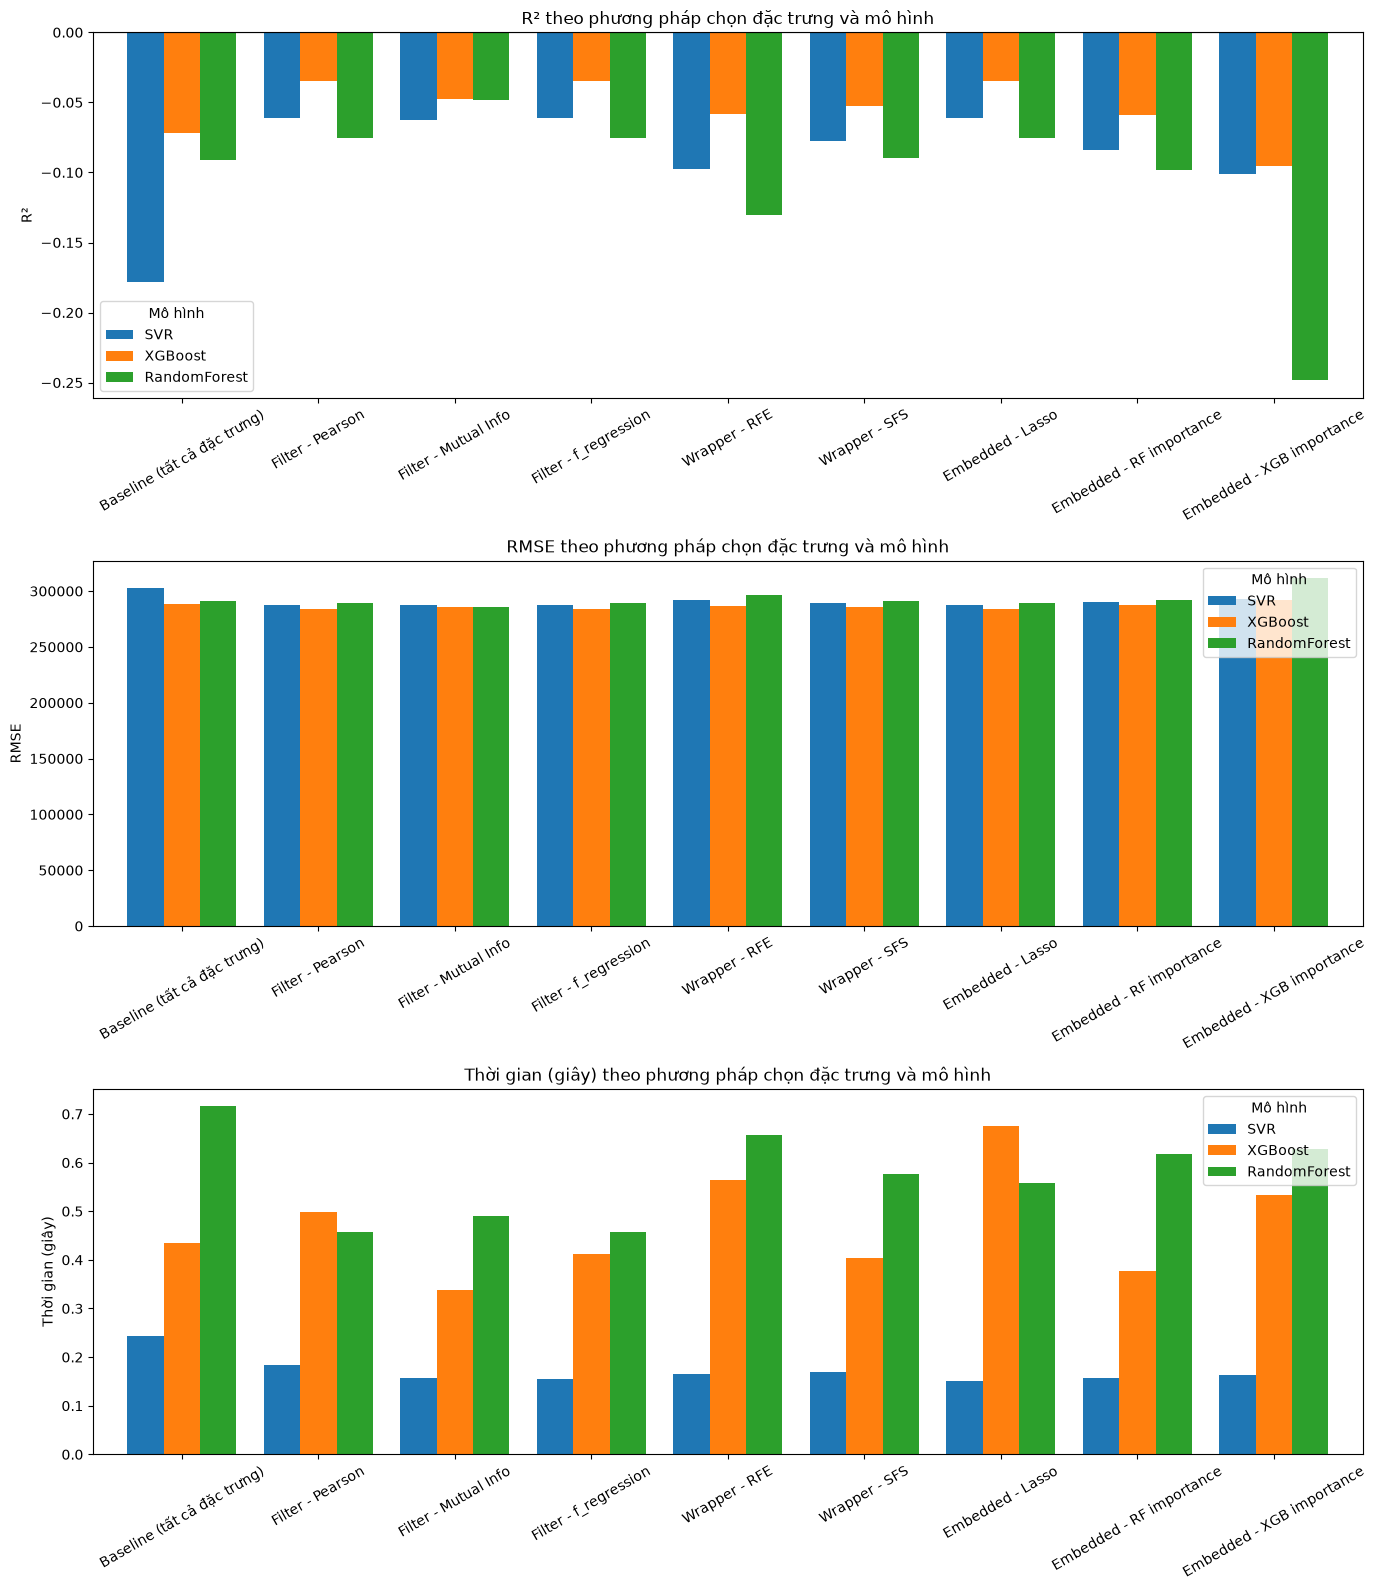

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
for ax, (metric, label) in zip(axes, [("R2", "R²"), ("RMSE", "RMSE"), ("Time", "Thời gian (giây)")]):
    pv = all_results.pivot(index="Method", columns="Model", values=metric)[MODEL_ORDER]
    pv.plot.bar(ax=ax, width=0.8)
    ax.set_title(f"{label} theo phương pháp chọn đặc trưng và mô hình")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=30)
    if metric == "R2":
        ax.axhline(0, color="black", linewidth=0.8)
    ax.legend(title="Mô hình")
plt.tight_layout()
plt.show()

,Phương pháp,Đặc trưng được chọn
0,Filter - Pearson,"Floors, Condition_Fair, Bathrooms, Condition_G..."
1,Filter - Mutual Info,"Location_Rural, Condition_Fair, Condition_Good..."
2,Filter - f_regression,"Floors, Condition_Fair, Bathrooms, Condition_G..."
3,Wrapper - RFE,"Area, Bedrooms, Bathrooms, Floors, YearBuilt, ..."
4,Wrapper - SFS,"Bathrooms, Floors, Location_Suburban, Location..."
5,Embedded - Lasso,"Floors, Condition_Fair, Bathrooms, Condition_G..."
6,Embedded - RF importance,"Area, YearBuilt, Bedrooms, Bathrooms, Floors, ..."
7,Embedded - XGB importance,"Location_Urban, Location_Suburban, Location_Ru..."


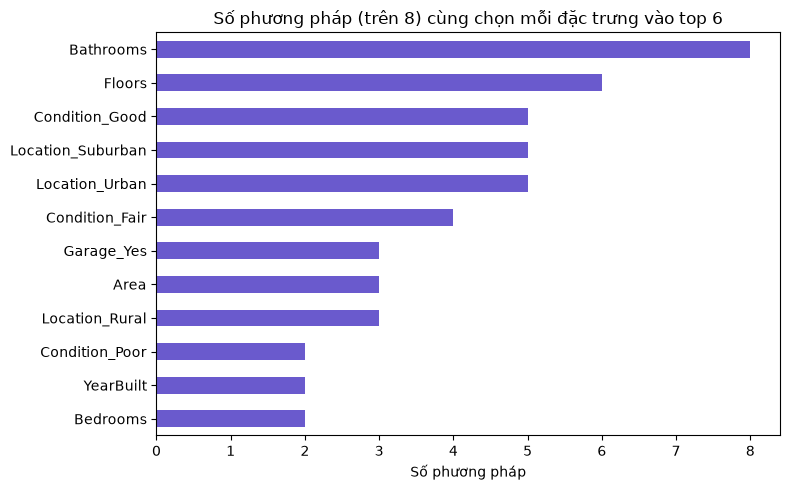

In [24]:
# Đặc trưng được chọn bởi từng phương pháp
selected_table = pd.DataFrame({
    "Phương pháp": list(filter_sets) + list(wrapper_embedded_sets),
    "Đặc trưng được chọn": [", ".join(v) for v in list(filter_sets.values()) + list(wrapper_embedded_sets.values())],
})
display(selected_table)

# Mức độ được nhiều phương pháp cùng chọn
freq = pd.Series([f for v in list(filter_sets.values()) + list(wrapper_embedded_sets.values()) for f in v]).value_counts()
freq.sort_values().plot.barh(figsize=(8, 5), color="slateblue")
plt.title(f"Số phương pháp (trên 8) cùng chọn mỗi đặc trưng vào top {TOP_K}")
plt.xlabel("Số phương pháp")
plt.tight_layout()
plt.show()